## Wahyu Pebrianto, M.T.

Overviews
1. Introduction

2. Analisis Univariate

3. Analisis Bivariate

4. Analisis Multivariate

5. Kesimpulan

### 1. Introduction

*Tujuan:* 
- Memahami bagaimana visualisasi data membantu mengeksplorasi data.
- Menemukan pola tersembunyi sebelum training model.

1.1. Import Package yang diperlukan

In [5]:
from pymongo import MongoClient
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Konfigurasi visualisasi
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.2. Connect to MongoDB

In [8]:
client = MongoClient("mongodb://localhost:27017/")
db = client["titanic_db"]
data = pd.DataFrame(list(db["cleaned_data"].find()))

# Drop kolom _id jika ada
if '_id' in data.columns:
    data.drop('_id', axis=1, inplace=True)

data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,2
1,1,1,1,38.0,1,0,71.2833,0
2,1,3,1,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,0,35.0,0,0,8.0500,2


### 2. Analisis Univariate

- In statistics, "univariate" refers to data analysis that focuses on a single variable.
- Descriptive Statistics (karakteristik variabel), No Relationships:

2.1 Distribusi Penumpang yang Selamat

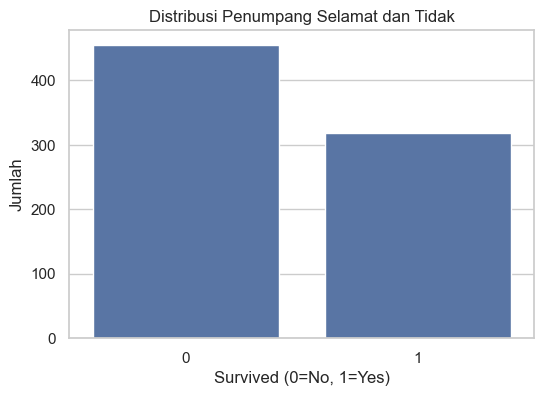

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=data)
plt.title("Distribusi Penumpang Selamat dan Tidak")
plt.xlabel("Survived (0=No, 1=Yes)")
plt.ylabel("Jumlah")
plt.show()

2.2 Distribusi Jenis Kelamin

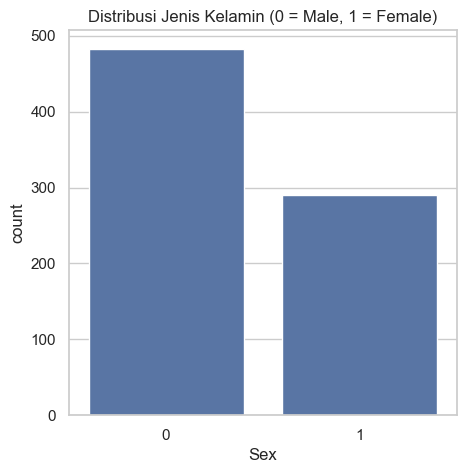

In [15]:
plt.figure(figsize=(5, 5))
sns.countplot(x="Sex", data=data)
plt.title("Distribusi Jenis Kelamin (0 = Male, 1 = Female)")
plt.savefig("vis_sex.png")

Interpretasi:
Mayoritas penumpang berjenis kelamin laki-laki. Hal ini akan menarik untuk dianalisis lebih lanjut apakah jenis kelamin berkaitan dengan peluang selamat.

2.3. Distribusi Umur

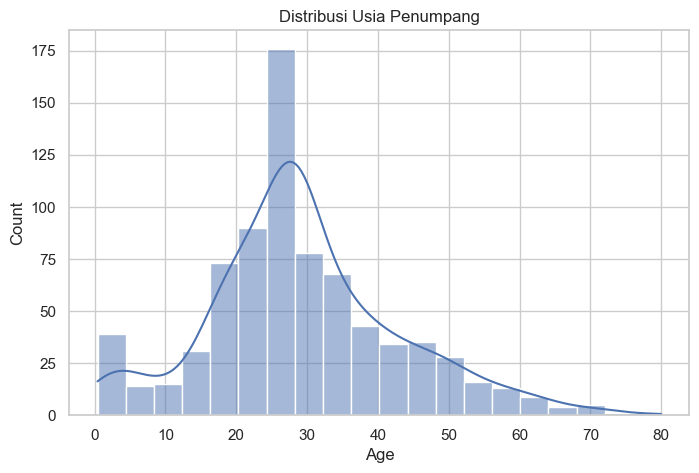

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Age"], bins=20, kde=True)
plt.title("Distribusi Usia Penumpang")
plt.savefig("vis_age.png")

Interpretasi:

Distribusi umur menunjukkan pola seperti distribusi normal. Sebagian besar penumpang berumur antara 20–40 tahun. Terdapat juga beberapa anak-anak dan lansia.

2.4 Distribusi Harga Tiket

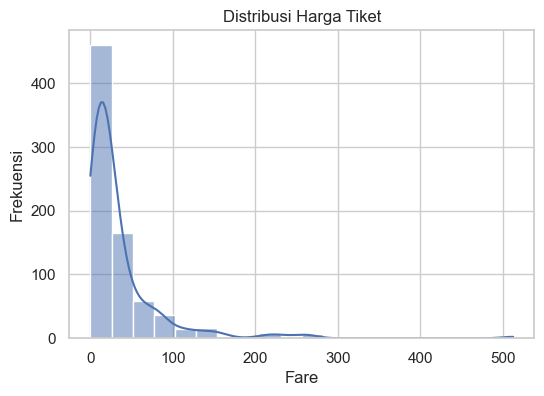

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(data["Fare"], bins=20, kde=True)
plt.title("Distribusi Harga Tiket")
plt.xlabel("Fare")
plt.ylabel("Frekuensi")
plt.show()

Interpretasi:

Distribusi harga tiket sangat miring ke kanan (right-skewed). Banyak penumpang membayar tiket murah, namun ada beberapa yang membayar sangat mahal (outlier).

### 3. Bivariate Analysis
Menganalisis hubungan antara dua fitur, terutama terhadap fitur target Survived.

3.1 Kelangsungan Hidup Berdasarkan Jenis Kelamin

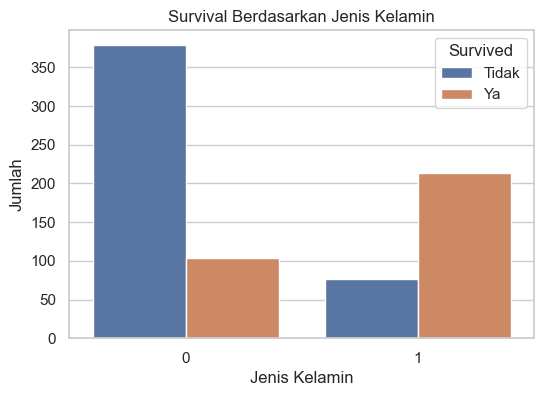

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=data)
plt.title("Survival Berdasarkan Jenis Kelamin")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Jumlah")
plt.legend(title="Survived", labels=["Tidak", "Ya"])
plt.show()

#0=male, 1=female

3.2 Kelangsungan Hidup Berdasarkan Kelas Tiket

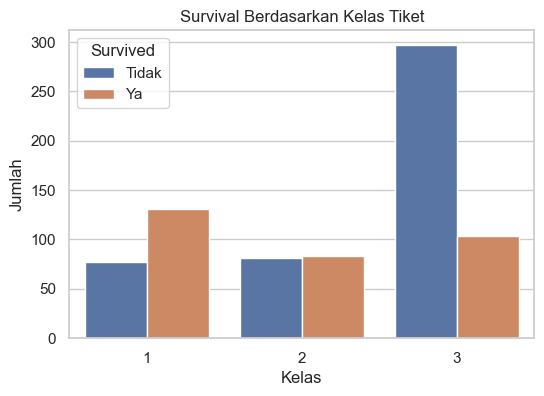

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Survived", data=data)
plt.title("Survival Berdasarkan Kelas Tiket")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.legend(title="Survived", labels=["Tidak", "Ya"])
plt.show()

3.3 Umur vs Kelangsungan Hidup (Boxplot)

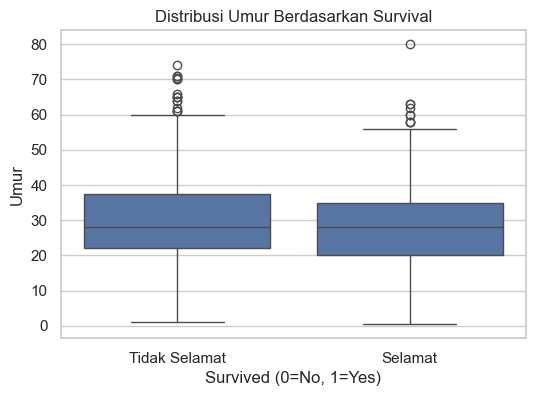

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Survived", y="Age", data=data)
plt.title("Distribusi Umur Berdasarkan Survival")
plt.xlabel("Survived (0=No, 1=Yes)")
plt.ylabel("Umur")
plt.xticks([0, 1], ["Tidak Selamat", "Selamat"])
plt.show()

Interpretasi:

Distribusi umur penumpang yang selamat sedikit lebih muda. Namun secara umum tidak terlalu jauh berbeda. Boxplot ini membantu melihat median dan outlier secara visual.

### 4. Multivariate Analysis

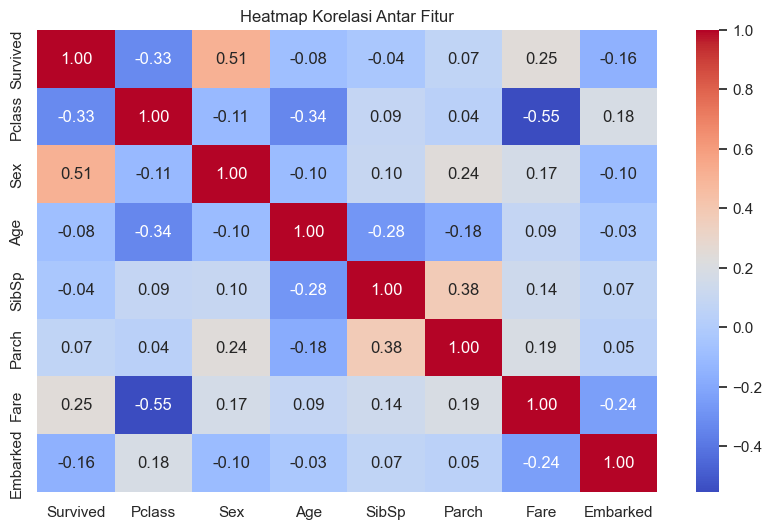

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

Interpretasi:

Ada korelasi negatif antara Pclass dan Fare, yang artinya penumpang di kelas lebih tinggi cenderung membayar tiket lebih mahal. Korelasi Survived dengan fitur lain relatif kecil tapi bisa memberikan insight tambahan.

In [31]:
import plotly.express as px

# Visualisasi interaktif Age vs Fare berdasarkan Survival
fig = px.scatter(data, x="Age", y="Fare", color="Survived",
                 title="Usia vs Harga Tiket berdasarkan Survival",
                 labels={"Survived": "Status (0=No, 1=Yes)"})
fig.show()

Interpretasi:

Visualisasi ini membantu mengeksplorasi hubungan tiga fitur sekaligus: umur, harga tiket, dan status survival. Kita bisa lihat bahwa penumpang yang membayar lebih mahal dan lebih muda cenderung memiliki peluang selamat yang lebih tinggi.

### 5. Kesimpulan

- Wanita dan penumpang kelas 1 memiliki peluang selamat lebih tinggi.
- Mayoritas penumpang berada di usia produktif (20–40 tahun).
- Harga tiket sangat bervariasi dan mempengaruhi tingkat survival.
- Visualisasi memberikan pemahaman awal yang kuat sebelum modeling dilakukan.